In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('credit_card_fraud_10k.csv')
print(df.head())

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

In [3]:
df.info

<bound method DataFrame.info of       transaction_id  amount  transaction_hour merchant_category  \
0                  1   84.47                22       Electronics   
1                  2  541.82                 3            Travel   
2                  3  237.01                17           Grocery   
3                  4  164.33                 4           Grocery   
4                  5   30.53                15              Food   
...              ...     ...               ...               ...   
9995            9996  350.91                22              Food   
9996            9997  410.04                 5          Clothing   
9997            9998  527.75                21       Electronics   
9998            9999   91.20                 2       Electronics   
9999           10000   44.06                 2          Clothing   

      foreign_transaction  location_mismatch  device_trust_score  \
0                       0                  0                  66   
1              

<Axes: >

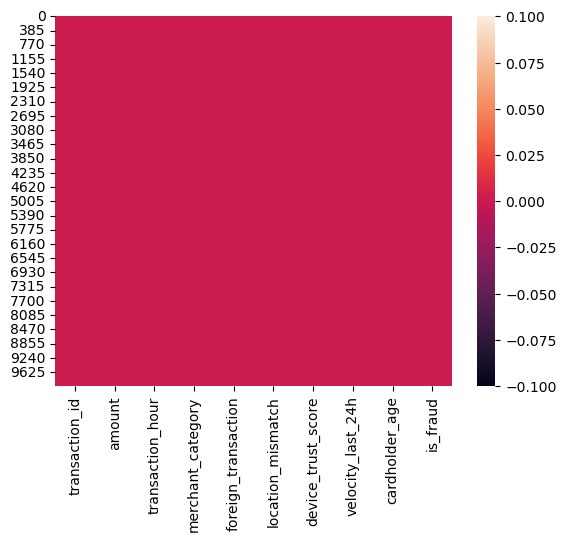

In [4]:
sns.heatmap(df.isnull())

<Axes: xlabel='is_fraud'>

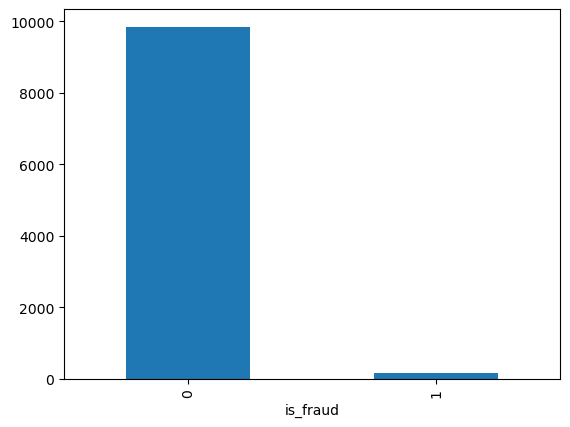

In [5]:
df["is_fraud"].value_counts().plot(kind="bar")

In [6]:
df.is_fraud

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: is_fraud, Length: 10000, dtype: int64

In [7]:
X = df.drop(["is_fraud","merchant_category"], axis=1)
y = df["is_fraud"]

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()

In [10]:
X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train , X_test , y_train , y_test = train_test_split(X_scaled , y , test_size=0.30, random_state=42)

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
lr = LogisticRegression()

In [15]:
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
y_pred = lr.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score


In [18]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}")

Accuracy: 0.99


In [19]:
from sklearn.metrics import classification_report

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2946
           1       0.87      0.48      0.62        54

    accuracy                           0.99      3000
   macro avg       0.93      0.74      0.81      3000
weighted avg       0.99      0.99      0.99      3000



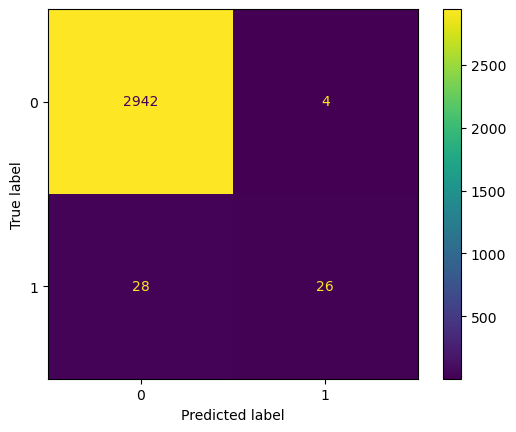

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

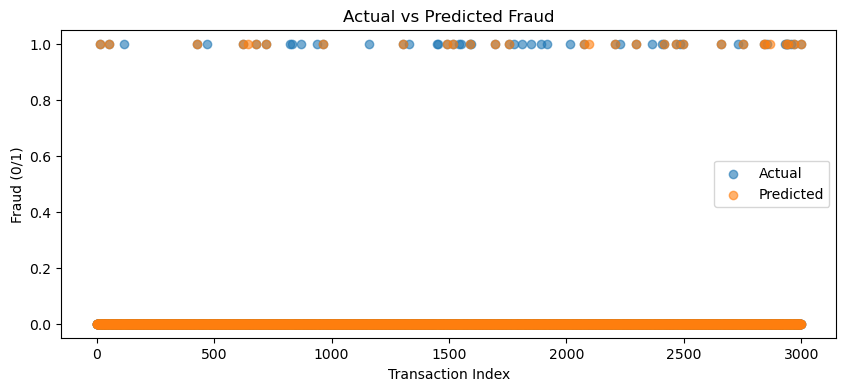

In [22]:
plt.figure(figsize=(10, 4))
plt.scatter(range(len(y_test)), y_test, label='Actual', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, label='Predicted', alpha=0.6)
plt.legend()
plt.xlabel("Transaction Index")
plt.ylabel("Fraud (0/1)")
plt.title("Actual vs Predicted Fraud")
plt.show()

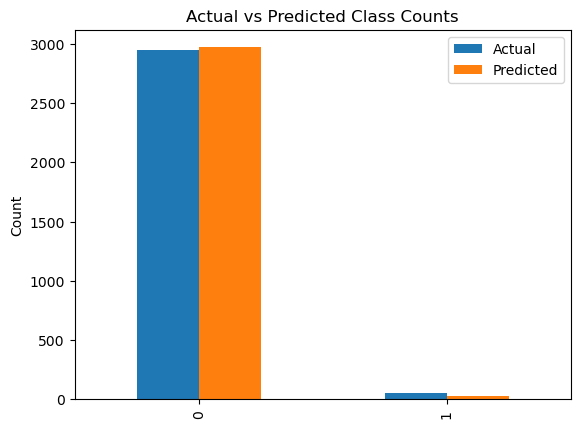

In [23]:
comparison = pd.DataFrame({
    'Actual': pd.Series(y_test).value_counts(),
    'Predicted': pd.Series(y_pred).value_counts()
})

comparison.plot(kind='bar')
plt.title("Actual vs Predicted Class Counts")
plt.ylabel("Count")
plt.show()